# 01 - Dataset et preprocessing

Objectif : vérifier le dataset synthétique, les images, les labels et préparer les fonctions de prétraitement.

Fichiers concernés : `data/synthetic_cases.csv`, `data/sample_images/`, `src/preprocessing.py`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
SAMPLE_IMAGES_DIR = DATA_DIR / "sample_images"
SRC_DIR = PROJECT_ROOT / "src"
API_DIR = PROJECT_ROOT / "api"
APP_DIR = PROJECT_ROOT / "app"
EVAL_DIR = PROJECT_ROOT / "eval"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
PROMPTS_DIR = PROJECT_ROOT / "prompts"
TESTS_DIR = PROJECT_ROOT / "tests"
OUTPUTS_DIR.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = c:\Users\Sarah Efrei\OneDrive\Desktop\2025-2026\S6\MasterCamp\Code du prof\ARVI-RX


## Colonnes officielles du dataset

Le CSV source officiel est `data/synthetic_cases.csv`. Ses colonnes réelles sont:
`case_id`, `image_path`, `source`, `label`, `split`, `quality`, `notes`.

Les exports produits par les notebooks peuvent renommer `label` en `expected_label`
et extraire `filename` depuis `image_path` pour rendre les tableaux plus lisibles.
Cette conversion est une vue de reporting; elle ne change pas le format source du dataset.

In [2]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(DATA_DIR / "synthetic_cases.csv")
display(df.head())
required_repo = {"case_id", "image_path", "source", "label", "split", "quality", "notes"}
required_prompt = {"case_id", "filename", "expected_label"}
print("Colonnes dépôt OK:", required_repo <= set(df.columns))
print("Colonnes consigne filename/expected_label OK:", required_prompt <= set(df.columns))
print("Labels invalides:", sorted(set(df["label"]) - {"normal", "suspected_opacity", "uncertain"}))
df["resolved_image_path"] = df["image_path"].apply(lambda p: PROJECT_ROOT / p)
df["image_exists"] = df["resolved_image_path"].apply(lambda p: p.exists())
display(df[["case_id", "image_path", "label", "quality", "image_exists"]].head())

,case_id,image_path,source,label,split,quality,notes
0,CXR_SYN_001,data/sample_images/CXR_SYN_001_normal.png,synthetic_toy,normal,smoke,good,synthetic normal-like image
1,CXR_SYN_002,data/sample_images/CXR_SYN_002_suspected_opaci...,synthetic_toy,suspected_opacity,smoke,good,synthetic opacity-like patch
2,CXR_SYN_003,data/sample_images/CXR_SYN_003_uncertain.png,synthetic_toy,uncertain,smoke,limited,synthetic low-quality ambiguous image
3,CXR_SYN_004,data/sample_images/CXR_SYN_004_normal.png,synthetic_toy,normal,smoke,good,synthetic normal-like image
4,CXR_SYN_005,data/sample_images/CXR_SYN_005_suspected_opaci...,synthetic_toy,suspected_opacity,smoke,good,synthetic opacity-like patch


Colonnes dépôt OK: True
Colonnes consigne filename/expected_label OK: False
Labels invalides: []


,case_id,image_path,label,quality,image_exists
0,CXR_SYN_001,data/sample_images/CXR_SYN_001_normal.png,normal,good,True
1,CXR_SYN_002,data/sample_images/CXR_SYN_002_suspected_opaci...,suspected_opacity,good,True
2,CXR_SYN_003,data/sample_images/CXR_SYN_003_uncertain.png,uncertain,limited,True
3,CXR_SYN_004,data/sample_images/CXR_SYN_004_normal.png,normal,good,True
4,CXR_SYN_005,data/sample_images/CXR_SYN_005_suspected_opaci...,suspected_opacity,good,True


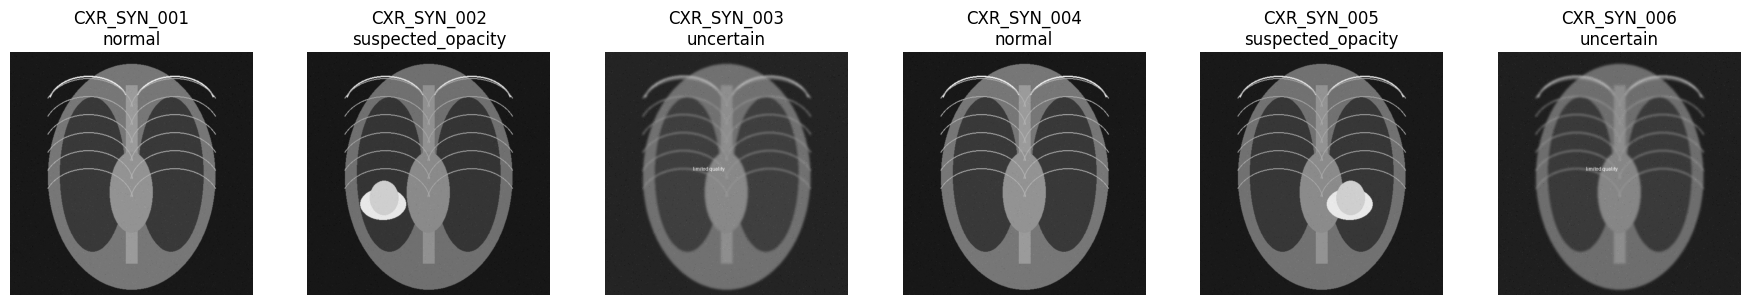

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

sample = df.groupby("label", group_keys=False).head(2).head(6)
fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
if len(sample) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, sample.iterrows()):
    ax.imshow(Image.open(row["resolved_image_path"]), cmap="gray")
    ax.set_title(f"{row['case_id']}\n{row['label']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
try:
    from src.preprocessing import load_image, basic_quality_flag
    img = load_image(df.loc[0, "resolved_image_path"])
    print("load_image OK:", img.size, img.mode)
    print("basic_quality_flag:", basic_quality_flag(df.loc[0, "resolved_image_path"]))
except Exception as exc:
    print("src/preprocessing.py à compléter:", repr(exc))

def get_image_info(image_path):
    with Image.open(image_path) as img:
        return {"width": img.width, "height": img.height, "mode": img.mode, "format": img.format}

def assess_image_quality(image_path):
    name = Path(image_path).name.lower()
    return "limited" if "uncertain" in name or "limited" in name else "good"

def preprocess_image(image_path, size=(512, 512)):
    return Image.open(image_path).convert("RGB").resize(size)

load_image OK: (512, 512) RGB
basic_quality_flag: good


## Limites du dataset synthétique

Les 30 cas sont équilibrés et utiles pour vérifier que le code charge les images,
parcourt le CSV, conserve les trois classes et produit des exports. En revanche,
ces images sont synthétiques et ne permettent pas de conclure à une performance
médicale. Elles servent de smoke test et de support pédagogique.

Point critique: le nom des fichiers contient souvent le label attendu
(`normal`, `suspected_opacity`, `uncertain`). Une baseline fondée sur le nom du
fichier peut donc obtenir un score parfait sans analyser réellement l'image.

In [5]:
summary = df.groupby(["label", "quality", "split"]).size().reset_index(name="n")
out = OUTPUTS_DIR / "dataset_summary.csv"
summary.to_csv(out, index=False)
print(out)
display(summary)

c:\Users\Sarah Efrei\OneDrive\Desktop\2025-2026\S6\MasterCamp\Code du prof\ARVI-RX\outputs\dataset_summary.csv


,label,quality,split,n
0,normal,good,final,3
1,normal,good,smoke,7
2,suspected_opacity,good,final,3
3,suspected_opacity,good,smoke,7
4,uncertain,limited,final,4
5,uncertain,limited,smoke,6


Conclusion : le dataset est réutilisable pour une validation technique du pipeline.
Il ne valide pas un modèle clinique. Le code final doit conserver clairement le
format source `image_path`/`label` et documenter toute conversion vers
`filename`/`expected_label` dans les outputs.